# C

In [190]:
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split

import time

### 1)

In [ ]:
digits = load_digits()

X = digits.data       
y = digits.target    

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [ ]:
nb_classe = 10

max_components = 8

gmm_models = {}
bics = {i:[] for i in range(nb_classe)}

for i in range(nb_classe):
    X_class = X_train[y_train == i]
    for j in range(1, max_components + 1, 1):
        gmm = GaussianMixture(n_components=j)
        gmm.fit(X_train)
        bics[i].append(gmm.bic(X_class))
    


    
    gmm_models[i] = GaussianMixture(n_components=np.argmin(bics[i])+1).fit(X_class)

    

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/victor/.local/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 2057, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
  File "/home/victor/.local/lib/python3.10/site-packages/IPython/core/ultratb.py", line 1288, in structured_traceback
    return FormattedTB.structured_traceback(
  File "/home/victor/.local/lib/python3.10/site-packages/IPython/core/ultratb.py", line 1177, in structured_traceback
    return VerboseTB.structured_traceback(
  File "/home/victor/.local/lib/python3.10/site-packages/IPython/core/ultratb.py", line 1030, in structured_traceback
    formatted_exception = self.format_exception_as_a_whole(etype, evalue, etb, number_of_lines_of_context,
  File "/home/victor/.local/lib/python3.10/site-packages/IPython/core/ultratb.py", line 935, in format_exception_as_a_whole
    self.get_records(etb, number_of_lines_of_context, tb_offset) if etb else []
  File "/home/victor/.local/lib/python3.1

In [194]:
crash = GaussianMixture(n_components=np.argmin(bics[i])+1).fit(X_class)

In [187]:
print(bics)

{0: [4275.52124466234, 10686.80854337378, 9786.876836314594, 8629.276766378225, 13738.611116029198, 16527.458229484146, 16882.392715604525, 23178.817981054628], 1: [10136.340150959257, 12529.54349325199, 11217.815046032869, 10067.842809539045, 15054.305089414018, 9119.311569624311, 14167.928441289565, 19186.077297494012], 2: [16182.650040243036, 15001.213773363626, 10586.581466756466, 9252.278273233045, 8689.750103362516, 19587.59247052892, 16346.022030158296, 23159.617354822018], 3: [15763.396243210398, 17153.033543730555, 16372.327457558533, 12580.464043682448, 12481.420388161161, 11374.067916302309, 15274.17687278425, 21758.782195128515], 4: [14757.350052056376, 17124.249015247173, 13193.594370781455, 7943.660756642435, 8763.80016931842, 21270.497580430245, 17134.850370077387, 24226.708885932167], 5: [15234.200251892484, 16716.172636683506, 17852.10252098666, 11108.312960645198, 9713.402509848289, 12003.86702160805, 19052.086573799228, 20508.001771035342], 6: [6709.350000934167, 113

Nombre optimal de composantes pour la classe 0: 1
Nombre optimal de composantes pour la classe 1: 1
Nombre optimal de composantes pour la classe 2: 5
Nombre optimal de composantes pour la classe 3: 4
Nombre optimal de composantes pour la classe 4: 4
Nombre optimal de composantes pour la classe 5: 5
Nombre optimal de composantes pour la classe 6: 1
Nombre optimal de composantes pour la classe 7: 5
Nombre optimal de composantes pour la classe 8: 6
Nombre optimal de composantes pour la classe 9: 2


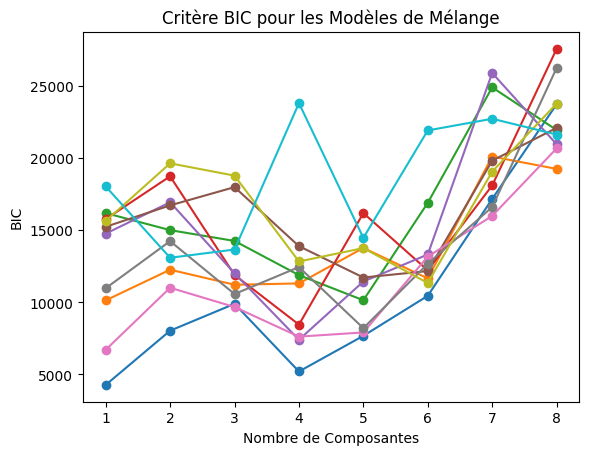

In [196]:
for i in range(nb_classe):
    plt.plot(range(1, max_components + 1, 1), bics[i], marker='o')
    plt.xlabel('Nombre de Composantes')
    plt.ylabel('BIC')
    plt.title(f'Critère BIC pour les Modèles de Mélange')

    # Nombre optimal de composantes
    print(f'Nombre optimal de composantes pour la classe {i}: {np.argmin(bics[i]) + 1}')

plt.show()


1


AttributeError: 'AxesSubplot' object has no attribute 'flatten'

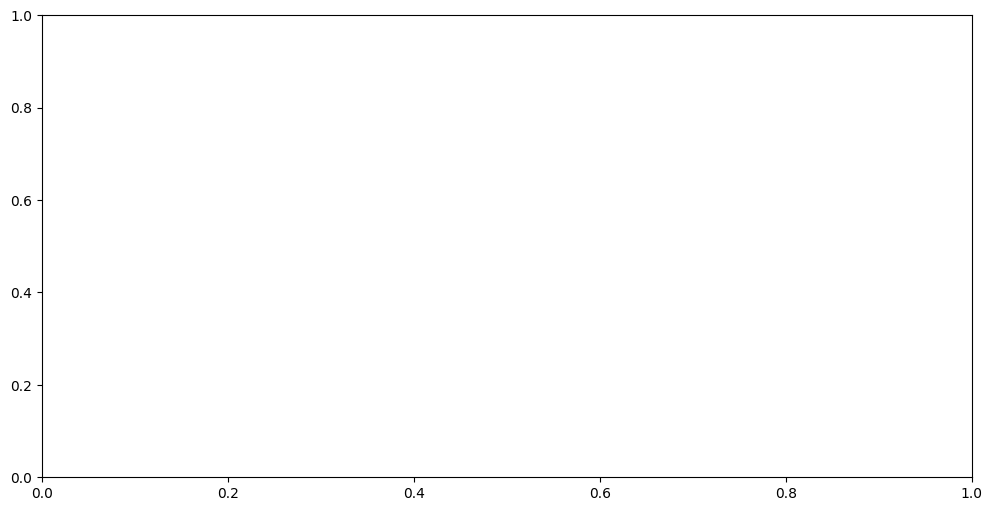

In [130]:
i=2

print(np.argmin(bics[i])+1)

# Afficher les moyennes des composantes sous forme d'images
means = gmm_models[i].means_.reshape(np.argmin(bics[i])+1, 8, 8)
fig, axes = plt.subplots(1, np.argmin(bics[i])+1, figsize=(12, 6))

for j, ax in enumerate(axes.flatten()):
    ax.imshow(means[j], cmap='gray')
    ax.axis('off')
    ax.set_title(f'Composante {j+1}')

plt.tight_layout()
plt.show()


In [167]:
print(gmm_models)

{0: GaussianMixture(), 1: GaussianMixture(n_components=5), 2: GaussianMixture(n_components=5), 3: GaussianMixture(n_components=4), 4: GaussianMixture(n_components=4), 5: GaussianMixture(n_components=5), 6: GaussianMixture(), 7: GaussianMixture(), 8: GaussianMixture(n_components=5), 9: GaussianMixture(n_components=4)}


Précision du classifieur GMM : 0.93


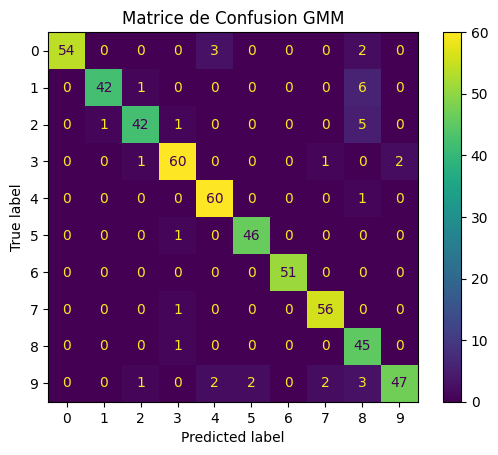

In [199]:
predictions = []

for x in X_test:
    debut = time.time()
    # Calculer la vraisemblance pour chaque classe
    likelihoods = {class_label: g.score_samples([x])[0] for class_label, g in gmm_models.items()}
    # Prédire la classe avec la vraisemblance maximale
    predicted_class = max(likelihoods, key=likelihoods.get)
    predictions.append(predicted_class)


y_pred = np.array(predictions)

accuracy = accuracy_score(y_test, y_pred)
print(f'Précision du classifieur GMM : {accuracy:.2f}')

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Matrice de Confusion GMM')
plt.show()